In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
import pandas as pd

In [16]:
x,y = make_moons(n_samples=500, noise=0.2)

In [17]:
df = {"x1":x[:,0],"x2":x[:,1],"y":y}

In [18]:
dataset = pd.DataFrame(df)

In [19]:
dataset.head(3)

,x1,x2,y
0,-1.160509,0.045788,0
1,0.136421,0.542507,1
2,0.587534,1.259903,0


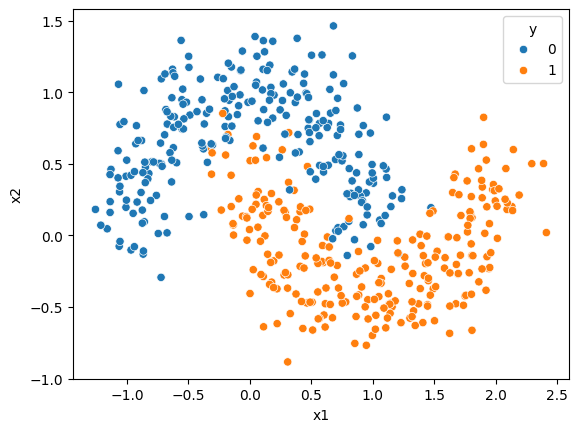

In [20]:
sns.scatterplot(x="x1",y="x2",data = dataset,hue="y")
plt.show()

split data

In [21]:
x_a = dataset.iloc[:,:-1]
y_a = dataset["y"]

train test spliting

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.25,random_state=42)

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# ***Train data using DecisionTreeClassifier***

In [27]:
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)
dt.score(x_train,y_train)*100, dt.score(x_test,y_test)*100

(100.0, 92.0)

# ***Train data using SVC***

In [29]:
sv = SVC()
sv.fit(x_train,y_train)
sv.score(x_train,y_train)*100, sv.score(x_test,y_test)*100

(93.60000000000001, 94.66666666666667)

# ***Train data using GaussianNB***

In [48]:
gnb = GaussianNB()
gnb.fit(x_train,y_train)
gnb.score(x_train,y_train)*100, gnb.score(x_test,y_test)*100

(83.2, 85.06666666666666)

In [50]:
from sklearn.ensemble import VotingClassifier

In [51]:
li = [("dt1",DecisionTreeClassifier()),("sv1",SVC()),("gnb1",GaussianNB())]

In [52]:
vc = VotingClassifier(li)
vc.fit(x_train, y_train)

VotingClassifier(estimators=[('dt1', DecisionTreeClassifier()), ('sv1', SVC()),
                             ('gnb1', GaussianNB())])

In [53]:
vc.score(x_test,y_test)*100, vc.score(x_train,y_train)*100

(94.39999999999999, 94.39999999999999)

In [54]:
prd = {"dt":dt.predict(x_test),"svm":sv.predict(x_test),"gnb":gnb.predict(x_test),"vc":vc.predict(x_test)}

In [57]:
pd.DataFrame(prd)

,dt,svm,gnb,vc
0,1,1,1,1
1,0,0,0,0
2,0,0,0,0
3,1,1,1,1
4,0,0,0,0
...,...,...,...,...
370,1,1,1,1
371,0,0,0,0
372,0,0,1,0
373,0,0,0,0
